In [15]:
#General imports
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random
import math

In [16]:
#Sci-kit learn imports
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

In [17]:
#set plot formatting to seaborn's default
sns.set() 

In [18]:
%matplotlib inline

# Import pickle file

In [19]:
import joblib

# Load the dictionary back from the file
data = joblib.load('..\Data\spotify_modeling_data.pkl')

# Unpack the variables
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

print(X_train.shape)

(17960, 41)


In [20]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17960 entries, 15107 to 15795
Data columns (total 41 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   danceability                        17960 non-null  float64
 1   energy                              17960 non-null  float64
 2   loudness                            17960 non-null  float64
 3   mode                                17960 non-null  int64  
 4   speechiness                         17960 non-null  float64
 5   acousticness                        17960 non-null  float64
 6   instrumentalness                    17960 non-null  float64
 7   liveness                            17960 non-null  float64
 8   valence                             17960 non-null  float64
 9   tempo                               17960 non-null  float64
 10  track_occurences                    17960 non-null  float64
 11  duration_sec                        17960 

# 1. Ridge Regression

In [21]:
from sklearn.linear_model import Ridge

# 1. Initialize the Ridge Regressor
ridge = Ridge()

# 2. Define the parameter grid
# 'alpha' is the regularization strength (higher = more penalty on large coefficients)
param_grid = {
    'alpha': [0.1, 1.0, 10.0, 100.0],
    'solver': ['auto', 'saga']
}

# 3. Initialize GridSearchCV
grid_search_ridge = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='neg_mean_absolute_error',
    verbose=1
)

# 4. Fit the model
grid_search_ridge.fit(X_train, y_train)

# 5. Best results
print(f"Best Parameters: {grid_search_ridge.best_params_}")
print(f"Best CV MAE: {-grid_search_ridge.best_score_:.2f}")

# 6. Evaluation on Test Set
best_ridge = grid_search_ridge.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)

print()
print(f"Test MAE: {mean_absolute_error(y_test, y_pred_ridge):.2f}")
print(f"Test MAPE: {mean_absolute_percentage_error(y_test, y_pred_ridge)*100:.2f}%")
print(f"Test R2 Score: {r2_score(y_test, y_pred_ridge):.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'alpha': 0.1, 'solver': 'auto'}
Best CV MAE: 14.69

Test MAE: 14.71
Test MAPE: 168.19%
Test R2 Score: 0.1960


# 2. Random Forest

In [22]:
# Note that this cell may take a while to run! (5-10 minutes on my machine)
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [10, 20],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_split': [2, 5]
}

# n_jobs=-1 uses all CPU cores; verbose=1 shows progress
grid_search = GridSearchCV(estimator=rf, 
                           param_grid=param_grid, 
                           cv=5, 
                           n_jobs=-1, 
                           scoring='neg_mean_absolute_error', #use neg so higher is better
                           verbose=1)

grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV MAE: {-grid_search.best_score_:.2f}")

best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

print()
print(f"Test MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Test MAPE: {mean_absolute_percentage_error(y_test, y_pred)*100:.2f}%")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters: {'max_depth': 20, 'max_features': None, 'min_samples_split': 5, 'n_estimators': 500}
Best CV MAE: 14.02

Test MAE: 13.95
Test MAPE: 155.58%
R2 Score: 0.2629


# 3. XGBoost

In [23]:
import xgboost as xgb

# 1. Initialize the XGBoost Regressor
# verbosity=0 keeps the output clean
xgb_model = xgb.XGBRegressor(random_state=42, objective='reg:squarederror')

# 2. Define the parameter grid
# We focus on learning_rate and max_depth to prevent overfitting
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [5, 10],
    'subsample': [0.8, 1.0]
}

# 3. Initialize GridSearchCV
grid_search_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='neg_mean_absolute_error',
    verbose=1
)

# 4. Fit the model
grid_search_xgb.fit(X_train, y_train)

# 5. Best results
print(f"Best Parameters: {grid_search_xgb.best_params_}")
print(f"Best CV MAE: {-grid_search_xgb.best_score_:.2f}")

# 6. Evaluation on Test Set
best_xgb = grid_search_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

print()
print(f"Test MAE: {mean_absolute_error(y_test, y_pred_xgb):.2f}")
print(f"Test MAPE: {mean_absolute_percentage_error(y_test, y_pred_xgb)*100:.2f}%")
print(f"Test R2 Score: {r2_score(y_test, y_pred_xgb):.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
Best CV MAE: 13.99

Test MAE: 13.95
Test MAPE: 156.50%
Test R2 Score: 0.2618


# Residual Plot
### Given that all these models are performing poorly, I would like to see if there is a particular feature that is giving the model trouble

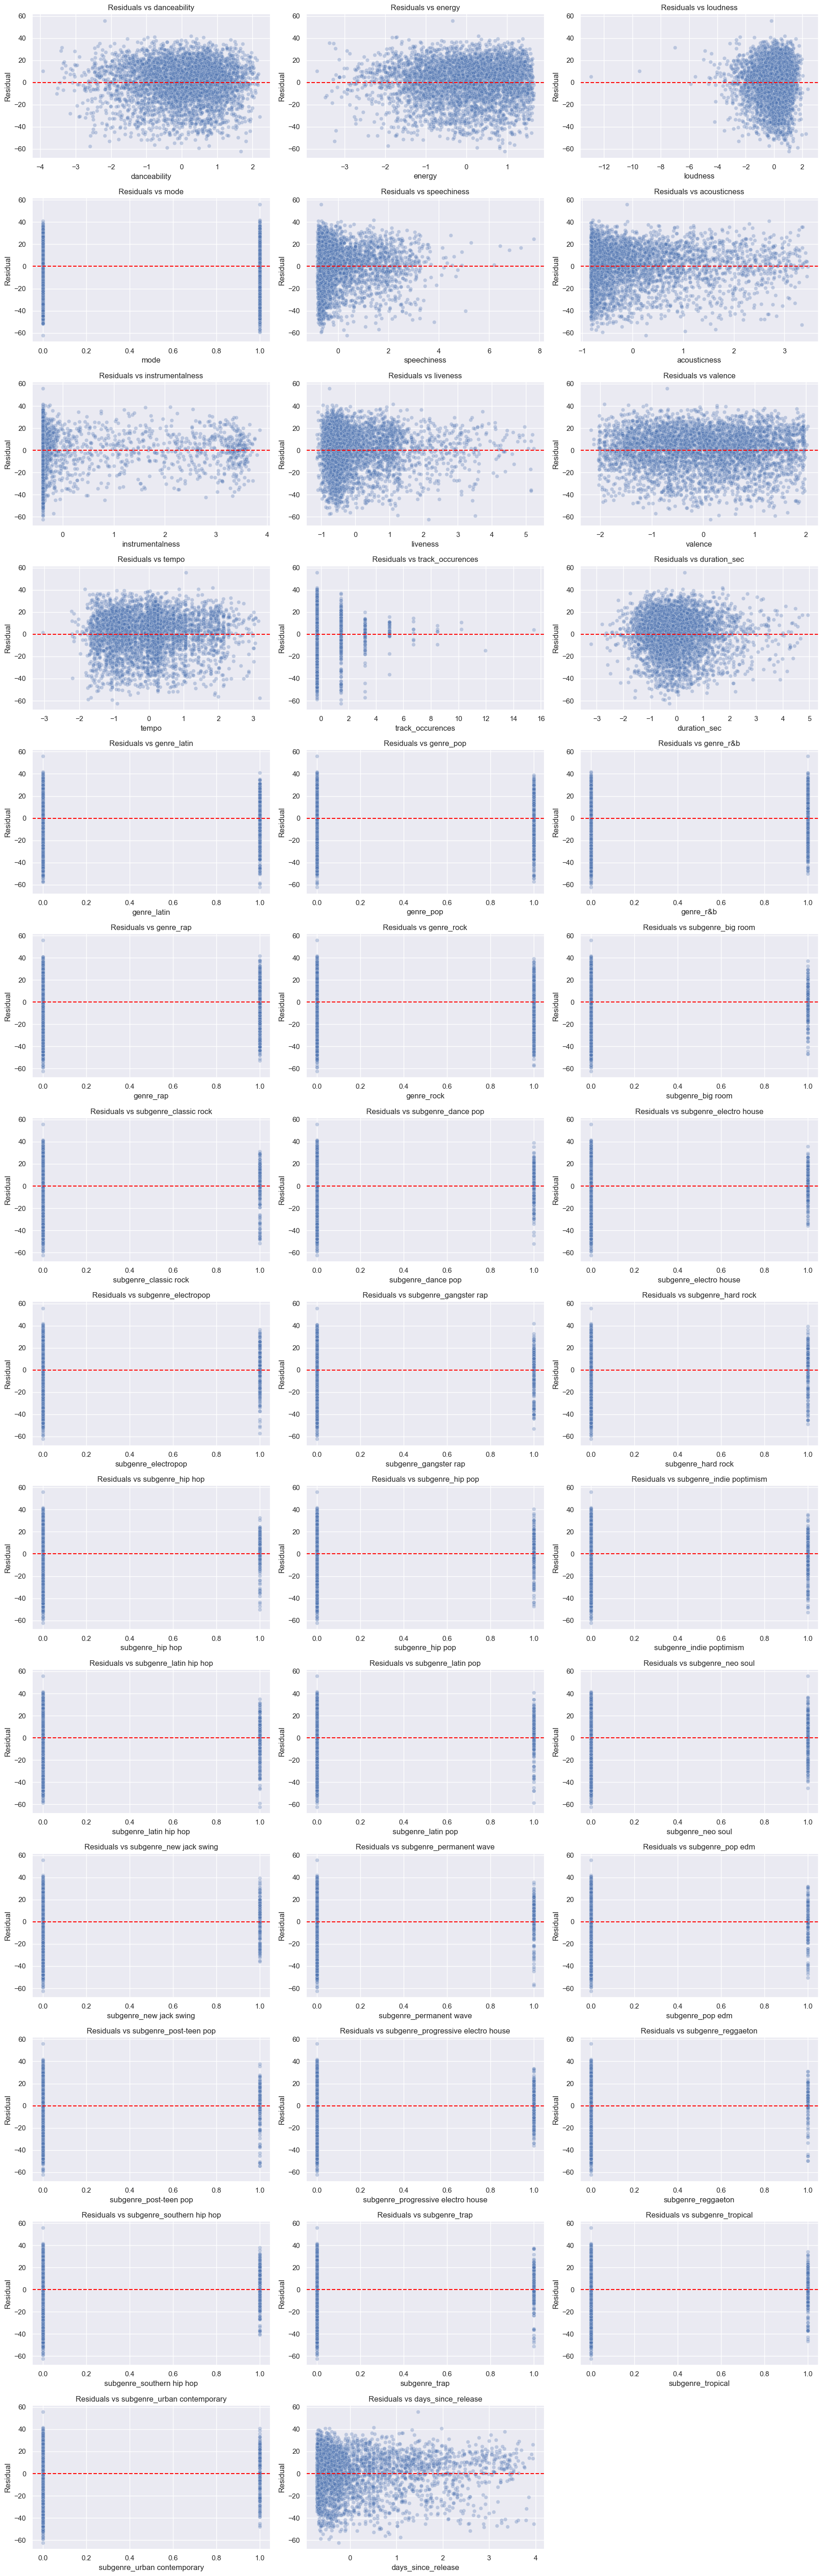

In [24]:
# Initialize results_df and calculate residuals
results_df = X_test.copy()
results_df['Residual'] = y_test - y_pred_xgb

# 1. Get all feature names
features = X_test.columns.tolist()
num_features = len(features)

# 2. Calculate grid dimensions (e.g., 3 columns wide)
cols = 3
rows = math.ceil(num_features / cols)

# 3. Create the figure
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()  # Flatten to 1D array for easy looping

for i, col in enumerate(features):
    sns.scatterplot(data=results_df, x=col, y='Residual', alpha=0.3, ax=axes[i])
    axes[i].axhline(0, color='red', linestyle='--')
    axes[i].set_title(f'Residuals vs {col}')

# 4. Remove any empty subplots if features don't fill the grid perfectly
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Feature Importance

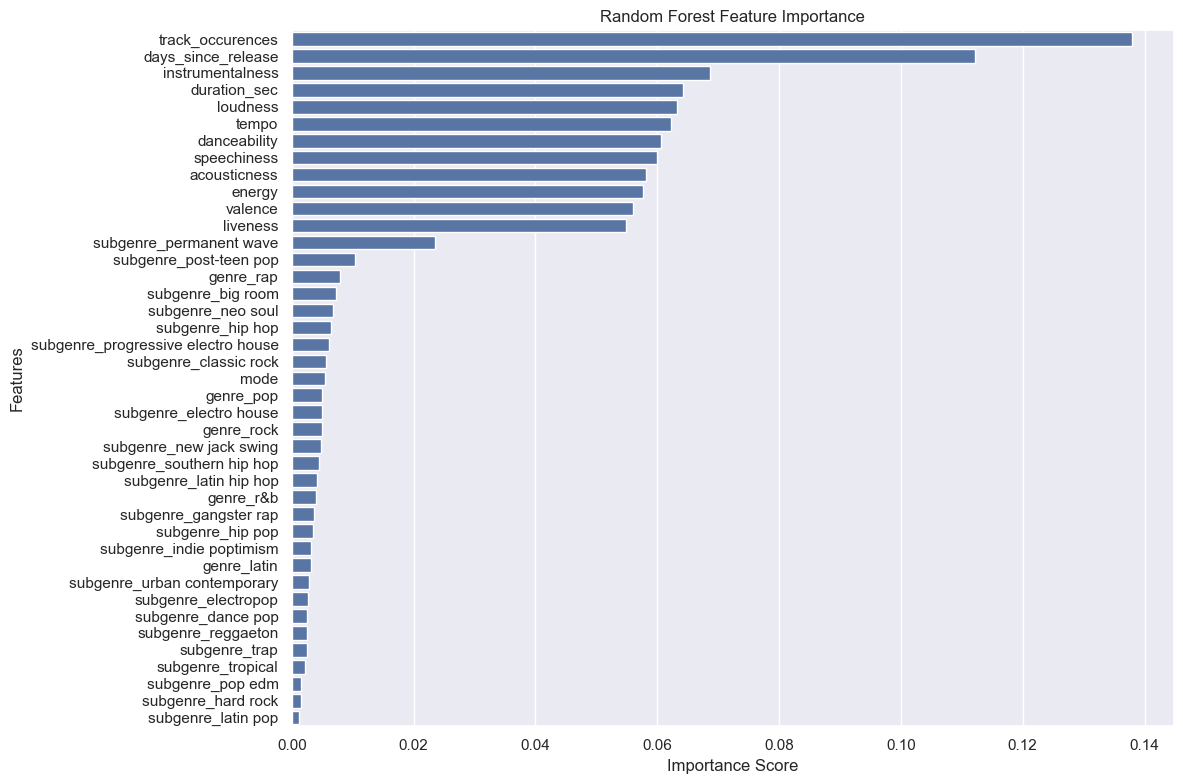

In [25]:
# Calculate and sort feature importances using the best random forest model
feature_importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
sorted_importances = feature_importances.sort_values(ascending=False)

# Plotting the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_importances.values, y=sorted_importances.index)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

For reference, this is the Problem Statement and Criteria for Success from my project proposal. I will dive into these in more detail in my report.

Problem Statement:
<br>What song attributes should record labels emphasize to increase popularity in their songs as of October 2023?

Criteria for Success:
<br>Define the top features (e.g., tempo, acousticness, loudness) that will maximize popularity of a song

# Summary

-I applied 3 different machine learning models to my data and compared their performance metrics.
<br>-I used a linear regression model (Ridge Regression) as a baseline. It runs very quickly, but also performs the worst.
<br>-Random Forest and XGBoost performed similarly. These types of models perform well with complex non-linear relationships, but are not as easy to explain as a linear model.
<br>-Random Forest is my chosen model beacuse it had the best performance metrics: MAE=13.95, MAPE=155.58%, R2 Score=0.2629
<br>-Mean Absolute Percent Error is over 100% which means that the absolute error is larger than the actual values. I believe this is because some popularities are quite low and the model over shot them by a large amount. 
<br>-Mean Absolute Error is 13.95 which means that on average the model is off by 13.95 units in either direction. Example: For a true popularity of 50, the model predicts between 36.05 and 63.95. 
<br>-R-squared is 0.2629 which means that the model explains around 26% of the variance
<br>-I would hope for better metrics, but there are many other factors that influence popularity such as advertising, marketing, artist recognition, lyrics, themes, etc. which are not captured with this dataset. 
<br>-I used 5-fold cross validation. This gave me results that are less sensitive to how the data is divided and better generalizes to the test dataset.
<br>-I used GridSearch to tune the hyperparameters. This allowed me to check a large slice of possible hyperparameter combinations, adjust, and run again easily.
<br>-Feature Importance: track_occurences and days_since_release are the top of the list. This makes sense becuase a track has to be popular to make it in a lot of playlists. Also, new songs are promoted widely and played on the radio so that boosts their popularity.

My Process:
<br><br>After all of my prevoius work, I was surprised when I first ran the models to see them performing so poorly: MAE was in the 20s and R-squared was around 0.11.
<br><br> I checked a few other samples on Kaggle to get ideas for how to improve my models. I realized that while they had better scores, they did not do almost any clean up of the data! They did not remove duplicate tracks based on track_id or based on artist-track combination name as I did. This gave me the idea to go back to the data wrangling step and create 3 new variables.
<br><br>track_occurences - counts how many times the track appears in the original dataset. This is a very important feature, because a popular track will naturally appear in many playlists
<br><br>genre and subgenre - I prevoiusly eliminated these variables because I believed users might mix different genres within playlists and thus would not be an accurate feature to use. From the feature importance chart, these are actually less important than the musically properties and could likely be eliminated. 
<br><br>track_occurences was a huge signal and boosted model performance to where it is now. This goes to show how a good understanding of the data can enhance feature engineering and lead to better models.